# Stage 3 — Final Calibration

**Requires NB1 (cache) and NB2 (winning objectives) to have been run first.**

Merges all 23 storms, applies the winning objective set, identifies the
Pareto-optimal ensemble and Euclidean optimum, generates the calibrated `.inp`,
and saves all 23 event hydrographs.

| Output | Path |
|--------|------|
| Full Pareto ensemble | `outputs/pareto/final/pareto_ensemble_full.csv` |
| Single optimum | `outputs/pareto/final/pareto_optimum.csv` |
| Calibrated model | `outputs/models/calibrated_baseline.inp` |
| Pareto grid | `outputs/metrics/final_pareto_grid.png` |
| Performance scatter | `outputs/metrics/final_calibration_scatter.png` |
| Hydrographs (23 events) | `outputs/metrics/hydrographs/hydrograph_*.png` |

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
import sys, os, subprocess
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

PROJECT_ROOT       = Path('.')
LOOCV_RESULTS_DIR  = PROJECT_ROOT / 'outputs' / 'results' / 'loocv'
FINAL_RESULTS_DIR  = PROJECT_ROOT / 'outputs' / 'results' / 'final_calibration'
PARETO_DIR         = PROJECT_ROOT / 'outputs' / 'pareto'  / 'final'
METRICS_DIR        = PROJECT_ROOT / 'outputs' / 'metrics'
HYDRO_DIR          = METRICS_DIR  / 'hydrographs'

for _d in [FINAL_RESULTS_DIR, PARETO_DIR, METRICS_DIR, HYDRO_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

CALIBRATION_CACHE  = LOOCV_RESULTS_DIR / 'loocv_calibration_cache.pkl'
LOOCV_SUMMARY_CSV  = LOOCV_RESULTS_DIR / 'loocv_validation_summary.csv'
OBJECTIVES_CACHE   = FINAL_RESULTS_DIR / 'combined_objectives.pkl'

# Override to None to read winning set from loocv_validation_summary.csv.
# Set to a list to manually specify objectives, e.g.:
#   ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']
WINNING_OBJECTIVE_OVERRIDE = None

print('NB3  -  Final Calibration')

NB3  -  Final Calibration


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle, logging
import numpy as np
import pandas as pd

from urban_runoff.config import (
    PARAMETER_GRID, FILTER_BOUNDS,
    PARETO_ENSEMBLE_FILENAME, PARETO_OPTIMUM_FILENAME,
)
from urban_runoff.calibration.cross_validation import (
    build_factor_combinations,
    validate_calibration_cache,
    merge_calibration_results,
    apply_filter_bounds,
)
from urban_runoff.calibration.objectives import (
    compute_objective_functions, build_objectives_dataframe,
)
from urban_runoff.optimization.pareto    import find_pareto_front, normalize_columns
from urban_runoff.optimization.selection import closest_row_to_origin, save_pareto_ensemble

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('nb3_final_calibration')

In [3]:
# ── Load winning objective set ────────────────────────────────────────────────
if WINNING_OBJECTIVE_OVERRIDE is not None:
    WINNING_OBJECTIVE_SET = WINNING_OBJECTIVE_OVERRIDE
    print(f'Using manually specified objectives: {WINNING_OBJECTIVE_SET}')
else:
    if not LOOCV_SUMMARY_CSV.exists():
        raise FileNotFoundError(
            f'Winning objectives not found:\n  {LOOCV_SUMMARY_CSV}\n\n'
            'Run 02_Analyze_CV_and_Select_Objectives.ipynb first.'
        )
    _summary = pd.read_csv(LOOCV_SUMMARY_CSV, index_col=0)
    _winning_name = _summary.index[0]
    WINNING_OBJECTIVE_SET = [o.strip() for o in _summary.loc[_winning_name, 'objectives'].split(',')]
    print(f'Winning set  : {_winning_name!r}')
    print(f'Objectives   : {WINNING_OBJECTIVE_SET}')
    print(f'Mean peak err: {_summary.loc[_winning_name, "mean_peak_rel_err"]:.4f}')

Winning set  : 'legacy_winner'
Objectives   : ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']
Mean peak err: 0.2834


In [4]:
# ── Load calibration cache — fail gracefully if missing or stale ──────────────
factor_combinations = build_factor_combinations()

if not CALIBRATION_CACHE.exists():
    raise FileNotFoundError(
        f'Calibration cache not found:\n  {CALIBRATION_CACHE}\n\n'
        'Run 01_Generate_LOOCV_Cache.ipynb first.'
    )

with open(CALIBRATION_CACHE, 'rb') as _f:
    _cached = pickle.load(_f)

if not validate_calibration_cache(_cached, factor_combinations):
    raise RuntimeError(
        'PARAMETER_GRID in config.py has changed since the cache was built.\n'
        'The cache is stale.  Run 01_Generate_LOOCV_Cache.ipynb to regenerate it.'
    )

cali_results_df_l = _cached['cali_results_df_l']
hydrograph_df_l   = _cached['hydrograph_df_l']
obs_hydrograph_df = _cached['obs_hydrograph_df']
logger.info('Cache loaded: %d events, %d combos each.',
            len(cali_results_df_l), len(cali_results_df_l[0]))

13:39:23 INFO     nb3_final_calibration: Cache loaded: 23 events, 1323 combos each.


In [5]:
# ── Merge ALL 23 events + compute objectives (with checkpoint) ────────────────
if OBJECTIVES_CACHE.exists():
    logger.info('Loading objectives cache from %s', OBJECTIVES_CACHE)
    with open(OBJECTIVES_CACHE, 'rb') as _f:
        _oc = pickle.load(_f)
    cali_merged   = _oc['cali_merged']
    hydro_merged  = _oc['hydro_merged']
    storm_obj_df  = _oc['storm_obj_df']
    peak_obj_df   = _oc['peak_obj_df']
    volume_obj_df = _oc['volume_obj_df']
    logger.info('Objectives loaded from cache.')
else:
    logger.info('Merging all %d events and computing objectives ...', len(cali_results_df_l))
    cali_merged  = merge_calibration_results(cali_results_df_l)
    hydro_merged = merge_calibration_results(hydrograph_df_l)
    storm_obj_df, peak_obj_df, volume_obj_df = compute_objective_functions(
        obs_hydrograph_df, cali_merged, hydro_merged,
    )
    with open(OBJECTIVES_CACHE, 'wb') as _f:
        pickle.dump({
            'cali_merged':   cali_merged,
            'hydro_merged':  hydro_merged,
            'storm_obj_df':  storm_obj_df,
            'peak_obj_df':   peak_obj_df,
            'volume_obj_df': volume_obj_df,
        }, _f)
    logger.info('Objectives cached to %s', OBJECTIVES_CACHE)

objectives_flat = build_objectives_dataframe(
    storm_obj_df, peak_obj_df, volume_obj_df,
    objective_names=WINNING_OBJECTIVE_SET,
)
print(f'Objectives shape: {objectives_flat.shape}')
print(objectives_flat[WINNING_OBJECTIVE_SET].describe().round(4))

13:39:23 INFO     nb3_final_calibration: Loading objectives cache from outputs\results\final_calibration\combined_objectives.pkl
13:39:23 INFO     nb3_final_calibration: Objectives loaded from cache.


Objectives shape: (1323, 4)
       peak_1-kge  volume_1-kge  peak_rmsd  peak_bias
count   1323.0000     1323.0000  1323.0000  1323.0000
mean       0.5183        0.8803    10.8871     7.6608
std        0.2736        0.5740     4.7790     5.4355
min        0.1199        0.1081     4.9101     0.0016
25%        0.2905        0.3833     6.9914     3.3132
50%        0.4644        0.7877     9.5163     6.6303
75%        0.6994        1.2696    13.6936    10.9382
max        1.3164        2.2604    26.5968    24.6053


In [6]:
# ── Physical bounds filter ────────────────────────────────────────────────────
# Edit FILTER_BOUNDS in config.py to restrict the Pareto search space.
# Default (all None) keeps the full grid.  No SWMM re-runs needed.

_n_before   = len(objectives_flat)
_valid_idx  = apply_filter_bounds(cali_merged, FILTER_BOUNDS)
cali_merged     = cali_merged.loc[_valid_idx]
objectives_flat = objectives_flat.loc[_valid_idx]
_n_after    = len(objectives_flat)

active = {k: v for k, v in FILTER_BOUNDS.items() if v is not None}
print(f'Bounds filter: {_n_before} -> {_n_after} rows '
      f'({_n_before - _n_after} dropped)' if _n_before != _n_after
      else f'Bounds filter: {_n_before} rows (no filter active)')
if active:
    print(f'Active bounds: {active}')

13:39:23 INFO     urban_runoff.calibration.cross_validation: apply_filter_bounds: kept 648 / 1323 rows after bounds filtering


Bounds filter: 1323 -> 648 rows (675 dropped)
Active bounds: {'imperviousness': (1.0, 1.5), 'storage': (0.1, 7.0)}


In [7]:
# ── Pareto front + save full ensemble ────────────────────────────────────────
pareto_obj_df = find_pareto_front(objectives_flat, normalize=True)

print(f'Total combinations : {len(objectives_flat)}')
print(f'Pareto front size  : {len(pareto_obj_df)} ({100*len(pareto_obj_df)/len(objectives_flat):.1f}%)')

save_pareto_ensemble(
    pareto_obj_df       = pareto_obj_df,
    full_calibration_df = cali_merged,
    output_dir          = PARETO_DIR,
    ensemble_filename   = PARETO_ENSEMBLE_FILENAME,
    optimum_filename    = PARETO_OPTIMUM_FILENAME,
)
print(f'Ensemble -> {PARETO_DIR / PARETO_ENSEMBLE_FILENAME}')
print(f'Optimum  -> {PARETO_DIR / PARETO_OPTIMUM_FILENAME}')

13:39:23 INFO     urban_runoff.optimization.pareto: find_pareto_front: 12/648 solutions are Pareto-optimal (1.9%)
13:39:23 INFO     urban_runoff.optimization.selection: Saved Pareto ensemble (12 members) to outputs\pareto\final\pareto_ensemble_full.csv
13:39:23 INFO     urban_runoff.optimization.selection: Saved Pareto optimum (index 708) to outputs\pareto\final\pareto_optimum.csv


Total combinations : 648
Pareto front size  : 12 (1.9%)
Ensemble -> outputs\pareto\final\pareto_ensemble_full.csv
Optimum  -> outputs\pareto\final\pareto_optimum.csv


In [8]:
# ── Inspect Pareto optimum ────────────────────────────────────────────────────
optimum_row  = closest_row_to_origin(pareto_obj_df)
optimum_full = cali_merged.loc[optimum_row.name]

factor_cols = [c for c in cali_merged.columns if c[0] == 'Factors']
print('=== Pareto Optimum (Euclidean closest to origin) ===')
print()
print('Factor values:')
for col in factor_cols:
    print(f'  {col[1]:<12}: {float(optimum_full[col]):.4f}')

_obj_norm = normalize_columns(objectives_flat.abs())
print()
print('Objective values (normalised):')
for obj in WINNING_OBJECTIVE_SET:
    print(f'  {obj:<18}: {_obj_norm.loc[optimum_row.name, obj]:.4f}')

=== Pareto Optimum (Euclidean closest to origin) ===

Factor values:
  IMP         : 1.0000
  Storage     : 7.0000
  Width       : 0.7000
  N           : 1.0000
  PCT_ZERO    : 1.0000
  CN          : 1.0000
  PCT_ROUTED  : 35.0000
  EVAP        : 4.0000

Objective values (normalised):
  peak_1-kge        : 0.0114
  volume_1-kge      : 0.0205
  peak_rmsd         : 0.0000
  peak_bias         : 0.0185


## Visualization

All plots read from cache — no SWMM re-runs.

In [9]:
# ── Visualization setup ──────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt

from urban_runoff.visualization.pareto_plots import plot_pareto_grid
from urban_runoff.visualization.scatter import (
    plot_performance_scatter, plot_hydrograph,
)

_obj_norm    = normalize_columns(objectives_flat.abs())
_pareto_norm = _obj_norm.loc[pareto_obj_df.index]
_opt_norm    = _obj_norm.loc[optimum_row.name]

print(f'Pareto front: {len(pareto_obj_df)} points  |  Optimum index: {optimum_row.name}')

Pareto front: 12 points  |  Optimum index: 708


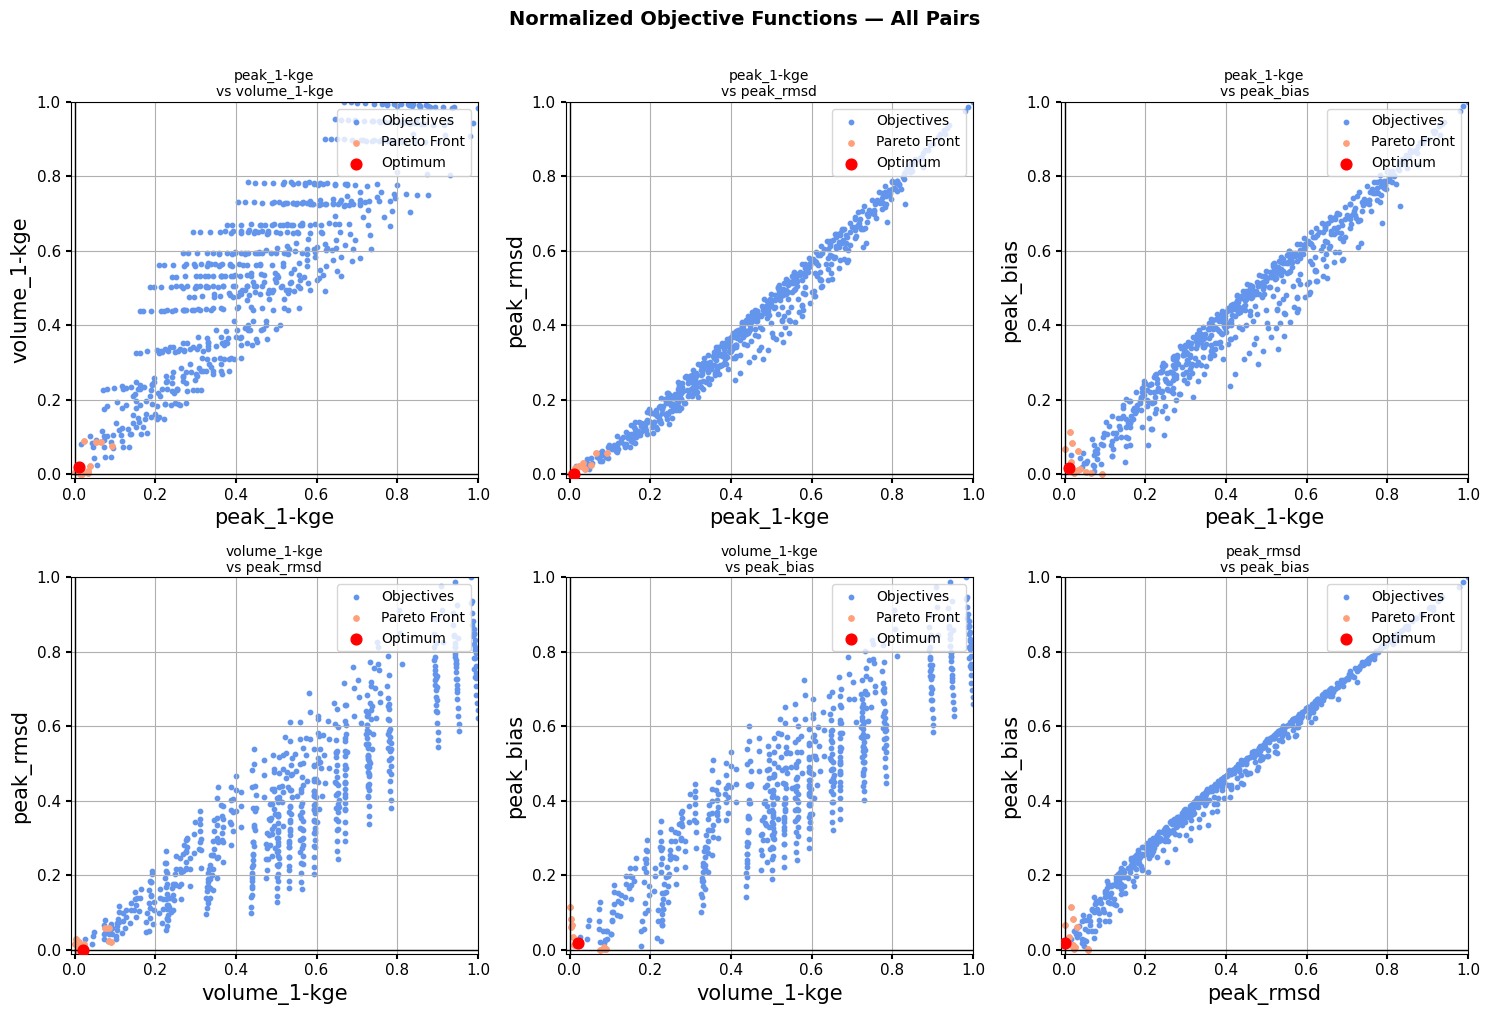

Saved -> outputs\metrics\final_pareto_grid.png


In [10]:
# ── Plot 1: Pareto front — all objective pairs ───────────────────────────────
fig1 = plot_pareto_grid(
    objectives_df   = _obj_norm,
    pareto_df       = _pareto_norm,
    optimum_row     = _opt_norm,
    objective_names = WINNING_OBJECTIVE_SET,
    save_path       = str(METRICS_DIR / 'final_pareto_grid.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "final_pareto_grid.png"}')

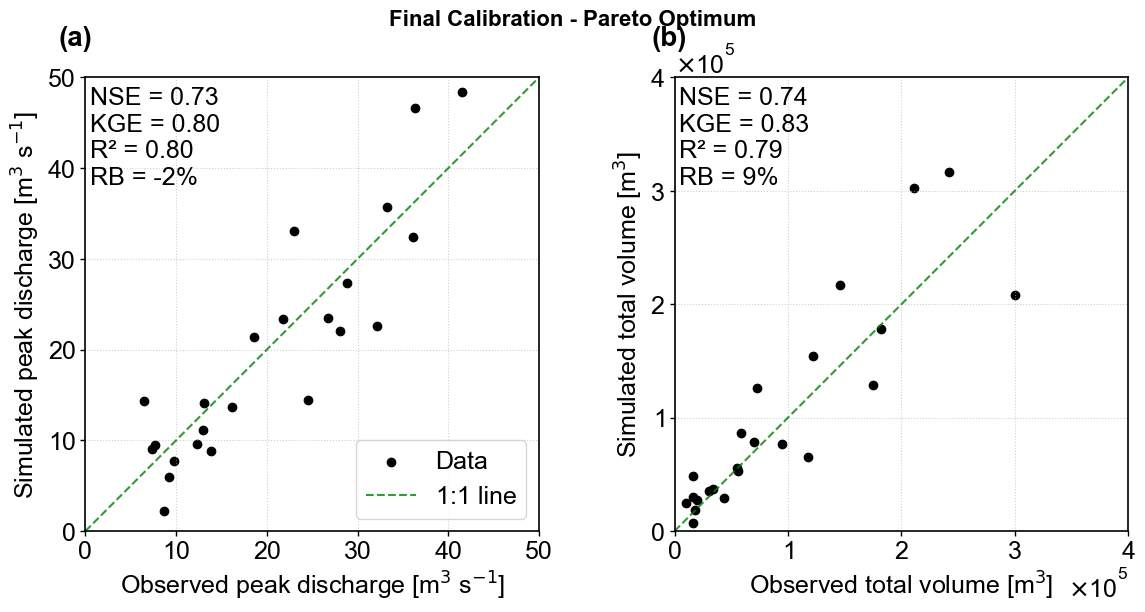

Saved -> outputs\metrics\final_calibration_scatter.png


In [11]:
# ── Plot 2: Final calibration performance scatter (obs vs sim) ───────────────
_obs_peaks_s = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
_obs_vols_s  = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60

_sim_peaks_df = cali_merged.xs('Max Runoff',   level=1, axis=1)
_sim_vols_df  = cali_merged.xs('Total Volume', level=1, axis=1)

_dates        = sorted(_obs_peaks_s.index)
obs_peaks_arr = _obs_peaks_s[_dates].values.astype(float)
sim_peaks_arr = _sim_peaks_df.loc[optimum_row.name, _dates].values.astype(float)
obs_vols_arr  = _obs_vols_s[_dates].values.astype(float)
# Total Volume in cali_merged is a raw CMS sum (per compute_storm_stats).
# Multiply by the 5-min timestep (300 s) to convert to m³, matching obs_vols_s.
sim_vols_arr  = _sim_vols_df.loc[optimum_row.name, _dates].values.astype(float) * 5 * 60

fig2 = plot_performance_scatter(
    obs_peaks    = obs_peaks_arr,
    sim_peaks    = sim_peaks_arr,
    obs_volumes  = obs_vols_arr,
    sim_volumes  = sim_vols_arr,
    title_suffix = 'Final Calibration - Pareto Optimum',
    save_path    = str(METRICS_DIR / 'final_calibration_scatter.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "final_calibration_scatter.png"}')

## Hydrographs — All 23 Events

One hydrograph per storm event at the Pareto optimum parameter set.
Dual-axis layout: discharge (obs/sim) on primary axis, inverted rainfall bars on top.
Stats box (NSE / KGE / R² / RB) shown on each plot.

Preview: 2012_01_13  |  Optimum row 708


D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\raznu\Anaconda3\envs\flood\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


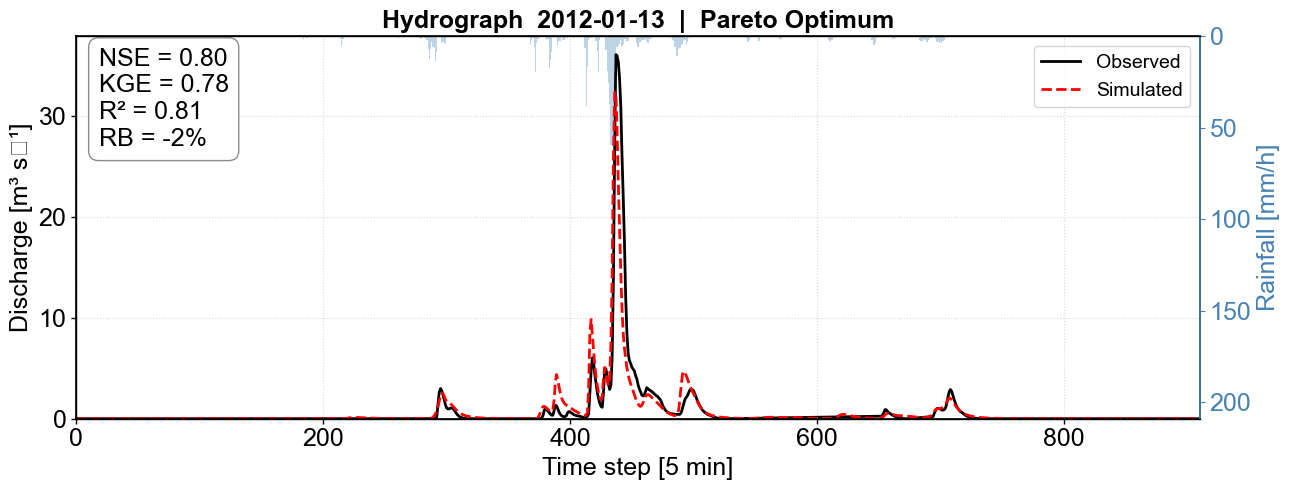

In [12]:
# ── Hydrograph — single event preview ────────────────────────────────────────
# Change EVENT_DATE to any event to preview a single hydrograph.
_all_dates = sorted(obs_hydrograph_df.index.get_level_values('Date').unique())
EVENT_DATE = _all_dates[0]   # default: earliest event

print(f'Preview: {EVENT_DATE}  |  Optimum row {optimum_row.name}')

fig_preview = plot_hydrograph(
    event_date        = EVENT_DATE,
    obs_hydrograph_df = obs_hydrograph_df,
    hydro_merged      = hydro_merged,
    row_idx           = optimum_row.name,
    title_suffix      = 'Pareto Optimum',
    save_path         = str(HYDRO_DIR / f'hydrograph_{EVENT_DATE}.png'),
)
plt.show()

In [13]:
# ── Batch hydrographs — all 23 events ────────────────────────────────────────
_all_dates = sorted(obs_hydrograph_df.index.get_level_values('Date').unique())

print(f'Generating {len(_all_dates)} hydrographs -> {HYDRO_DIR}')
for _i, _date in enumerate(_all_dates, 1):
    _save = str(HYDRO_DIR / f'hydrograph_{_date}.png')
    _fig  = plot_hydrograph(
        event_date        = _date,
        obs_hydrograph_df = obs_hydrograph_df,
        hydro_merged      = hydro_merged,
        row_idx           = optimum_row.name,
        title_suffix      = 'Pareto Optimum',
        save_path         = _save,
    )
    plt.close(_fig)
    print(f'  [{_i:2d}/{len(_all_dates)}] {_date}  saved')

print(f'\nAll {len(_all_dates)} hydrographs saved to {HYDRO_DIR}')

Generating 23 hydrographs -> outputs\metrics\hydrographs


D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


  [ 1/23] 2012_01_13  saved


D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


  [ 2/23] 2013_01_06  saved
  [ 3/23] 2014_12_14  saved


...

D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


  [21/23] 2019_12_13  saved
  [22/23] 2019_12_27  saved


D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


  [23/23] 2020_01_19  saved

All 23 hydrographs saved to outputs\metrics\hydrographs


D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:338: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
D:\MY_CODES\UrbanRunoffModeling_Refactored\urban_runoff\visualization\scatter.py:341: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


In [14]:
# ── Generate calibrated baseline .inp ─────────────────────────────────────────
# Reads pareto_optimum.csv (written above) and applies factors to the base .inp.
# Saves outputs/models/calibrated_baseline.inp.

_script = PROJECT_ROOT / 'generate_calibrated_baseline.py'
if not _script.exists():
    print(f'WARNING: {_script} not found — skipping .inp generation.')
else:
    _result = subprocess.run(
        [sys.executable, str(_script)],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT),
    )
    print(_result.stdout)
    if _result.returncode != 0:
        print('STDERR:', _result.stderr)

Reading Pareto optimum factors...
Calibrated parameter factors:
  imperviousness   = 1.0
  storage          = 7.0
  width            = 0.7
  n                = 1.0
  pct_zero         = 1.0
  cn               = 1.0
  pct_routed       = 35.0
  evaporation      = 4.0

Loading base model from:
  D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation\2012_01_13\raanana_28subcatchments.inp
Applying factors and writing to:
  d:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\models\calibrated_baseline.inp

Done. File size: 1007.8 KB

Calibratedbaseline .inp path:
  D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\models\calibrated_baseline.inp

